# 🏦 Loan Default Prediction — End-to-End Machine Learning Project

**Objective:** Predict whether a loan applicant is likely to **default** on a loan using classification models.

**Dataset:** `Loan_default.csv` — 255,347 records · 18 features  
**Target Variable:** `Default` (0 = No Default · 1 = Default)

---
### Project Workflow
1. Import Libraries & Configure Paths  
2. Load & Inspect Dataset  
3. Exploratory Data Analysis (EDA)  
4. Data Preprocessing & Encoding  
5. Train / Test Split + Scaling  
6. Model Training (Logistic Regression & Decision Tree)  
7. Model Evaluation & Comparison  
8. Improvements: Balanced LR · ROC-AUC · Threshold Tuning · Risk Tiers  
9. Save Best Model  
10. Conclusion


## 1. Import Libraries & Configure Output Paths

In [1]:
# ── Standard Library ──────────────────────────────────────────────────────
import warnings, os, glob
warnings.filterwarnings('ignore')

from pathlib import Path

# ── Data Manipulation ─────────────────────────────────────────────────────
import numpy  as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

matplotlib.rcParams['figure.dpi']     = 110
matplotlib.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid', palette='Set2')

# ── Scikit-learn ──────────────────────────────────────────────────────────
from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import LabelEncoder, StandardScaler
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from sklearn.metrics          import (accuracy_score, confusion_matrix,
                                       classification_report,
                                       ConfusionMatrixDisplay,
                                       roc_auc_score, roc_curve, f1_score)
from sklearn.impute            import SimpleImputer
import joblib

# ═══════════════════════════════════════════════════════════════════════════
#  ALL PLOTS WILL BE SAVED HERE — change this path if you want a different
#  location.  The folder is created automatically if it does not exist.
# ═══════════════════════════════════════════════════════════════════════════
PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Clean up any old PNG files scattered in the root project folder ───────
old_pngs = glob.glob("plot_*.png")
for f in old_pngs:
    os.remove(f)
    print(f"🗑  Removed old file: {f}")

if not old_pngs:
    print("✅  No stale root-level PNGs found.")

print(f"\n📁  All plots will be saved to: {PLOTS_DIR.resolve()}")
print(f"\n✅  All libraries imported successfully!")
print(f"    pandas {pd.__version__}  |  numpy {np.__version__}")


🗑  Removed old file: plot_01_target_distribution.png
🗑  Removed old file: plot_02_loan_amount.png
🗑  Removed old file: plot_03_income.png
🗑  Removed old file: plot_04_education.png
🗑  Removed old file: plot_05_employment.png
🗑  Removed old file: plot_06_credit_score.png
🗑  Removed old file: plot_07_correlation.png
🗑  Removed old file: plot_08_risk_factors.png
🗑  Removed old file: plot_09_confusion_matrices.png
🗑  Removed old file: plot_10_accuracy_comparison.png
🗑  Removed old file: plot_11_feature_importance.png

📁  All plots will be saved to: C:\Users\amjad\Projects\loan-default-analysis\plots

✅  All libraries imported successfully!
    pandas 3.0.3  |  numpy 2.4.4


## 2. Load & Inspect the Dataset

In [2]:
DATA_PATH = 'Loan_default.csv'
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()


Dataset shape : 255,347 rows × 18 columns


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [3]:
print("Column names and dtypes:")
print(df.dtypes)


Column names and dtypes:
LoanID                str
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education             str
EmploymentType        str
MaritalStatus         str
HasMortgage           str
HasDependents         str
LoanPurpose           str
HasCoSigner           str
Default             int64
dtype: object


In [4]:
df.describe(include='all')


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
count,255347,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347,255347,255347,255347,255347,255347,255347,255347.000000
unique,255347,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,4,3,2,2,5,2,NaN
top,I38PQUQS96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bachelor's,Part-time,Married,Yes,Yes,Business,Yes,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64366,64161,85302,127677,127742,51298,127701,NaN
mean,NaN,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.116128
std,NaN,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.320379
min,NaN,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,NaN,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
75%,NaN,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


In [5]:
missing = df.isnull().sum()
pct     = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print("✅  No missing values found.")
else:
    print(missing_df)


✅  No missing values found.


In [6]:
counts = df['Default'].value_counts()
print("Default distribution:")
print(f"  No Default (0) : {counts[0]:>7,}  ({counts[0]/len(df)*100:.1f}%)")
print(f"  Default    (1) : {counts[1]:>7,}  ({counts[1]/len(df)*100:.1f}%)")


Default distribution:
  No Default (0) : 225,694  (88.4%)
  Default    (1) :  29,653  (11.6%)


## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Variable — Loan Default Distribution

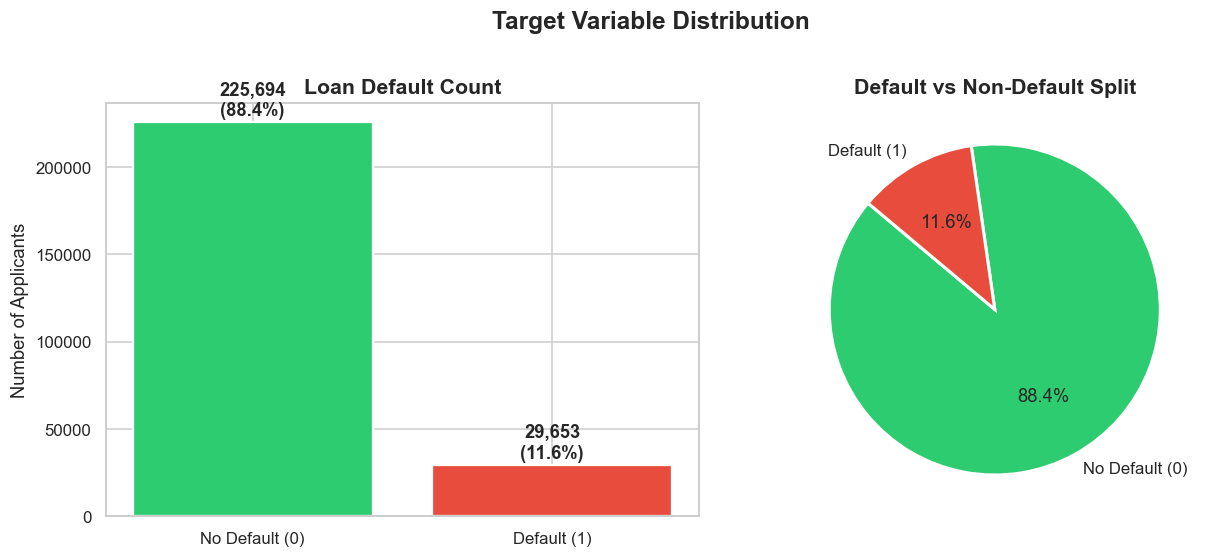

✅  Saved → plots\plot_01_target_distribution.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
counts = df['Default'].value_counts()
labels = ['No Default (0)', 'Default (1)']
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Loan Default Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Applicants')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1500, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontweight='bold')

axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Default vs Non-Default Split', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'plot_01_target_distribution.png', bbox_inches='tight')
plt.show()
print(f"✅  Saved → {PLOTS_DIR / 'plot_01_target_distribution.png'}")


### 3.2 Loan Amount Distribution

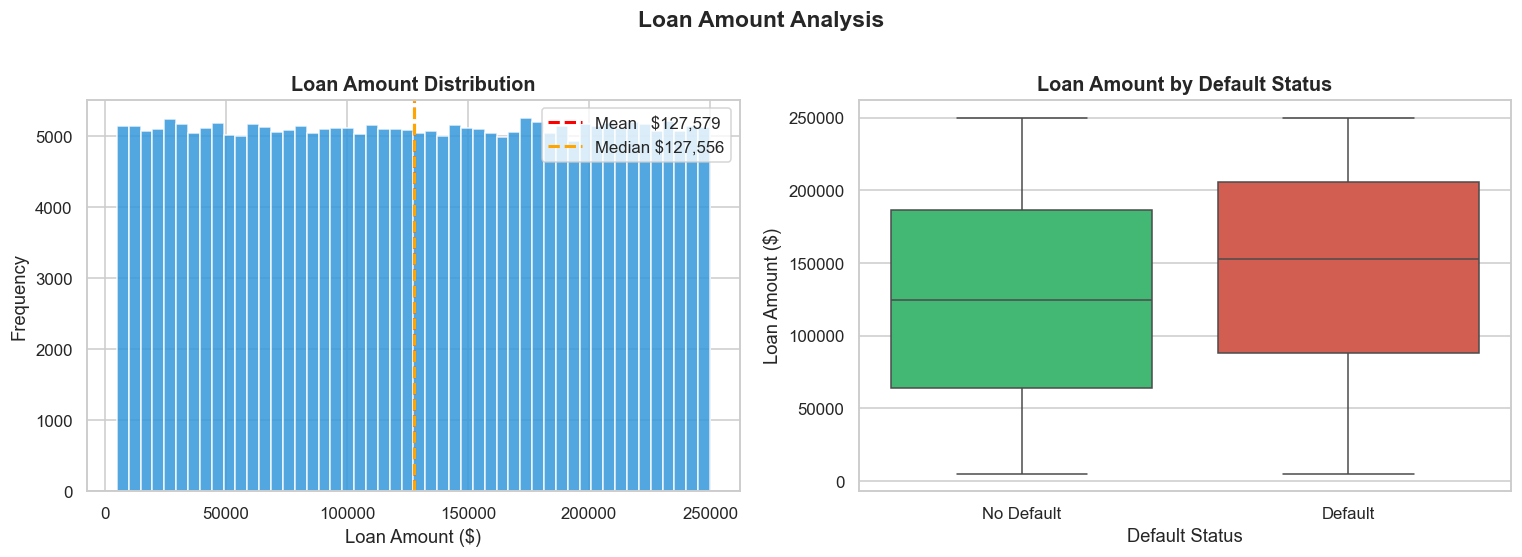

✅  Saved → plots\plot_02_loan_amount.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['LoanAmount'], bins=50, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axvline(df['LoanAmount'].mean(),   color='red',    linestyle='--', linewidth=2, label=f"Mean   ${df['LoanAmount'].mean():,.0f}")
axes[0].axvline(df['LoanAmount'].median(), color='orange', linestyle='--', linewidth=2, label=f"Median ${df['LoanAmount'].median():,.0f}")
axes[0].set_title('Loan Amount Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Loan Amount ($)'); axes[0].set_ylabel('Frequency'); axes[0].legend()

df_box = df[['LoanAmount','Default']].copy()
df_box['Default_Label'] = df_box['Default'].map({0:'No Default',1:'Default'})
sns.boxplot(x='Default_Label', y='LoanAmount', data=df_box,
            palette={'No Default':'#2ecc71','Default':'#e74c3c'}, ax=axes[1])
axes[1].set_title('Loan Amount by Default Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Default Status'); axes[1].set_ylabel('Loan Amount ($)')

plt.suptitle('Loan Amount Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'plot_02_loan_amount.png', bbox_inches='tight')
plt.show()
print(f"✅  Saved → {PLOTS_DIR / 'plot_02_loan_amount.png'}")


### 3.3 Applicant Income Distribution

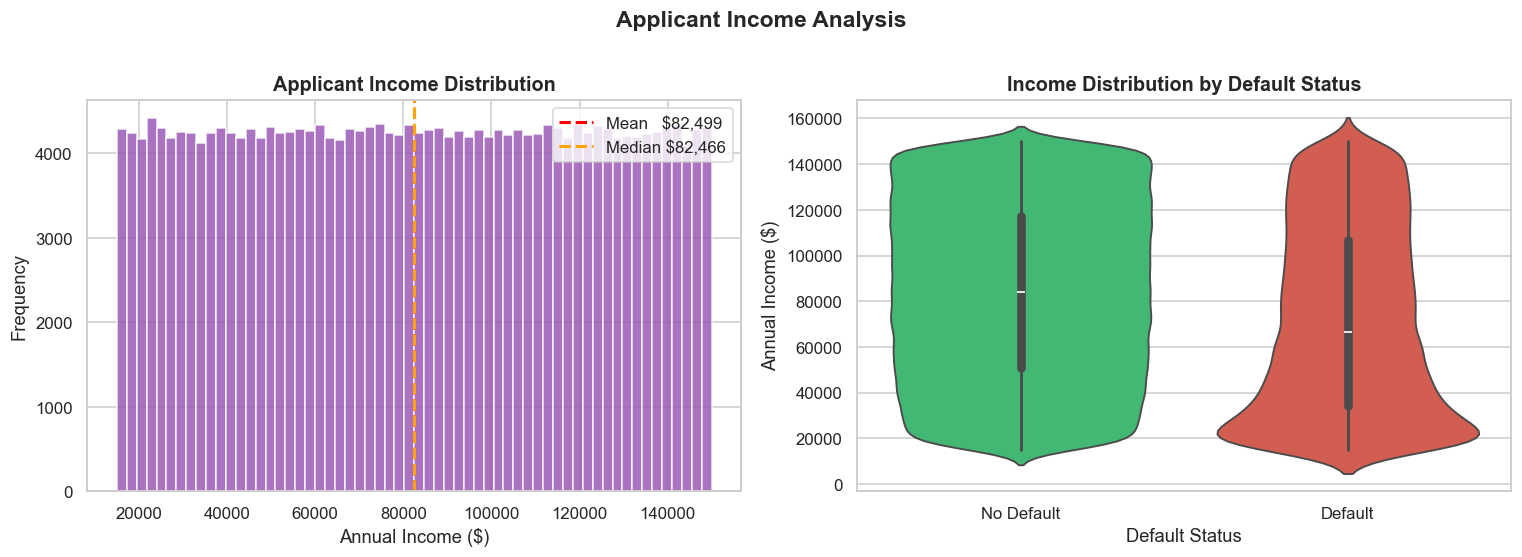

✅  Saved → plots\plot_03_income.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Income'], bins=60, color='#9b59b6', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Income'].mean(),   color='red',    linestyle='--', linewidth=2, label=f"Mean   ${df['Income'].mean():,.0f}")
axes[0].axvline(df['Income'].median(), color='orange', linestyle='--', linewidth=2, label=f"Median ${df['Income'].median():,.0f}")
axes[0].set_title('Applicant Income Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Annual Income ($)'); axes[0].set_ylabel('Frequency'); axes[0].legend()

df_box2 = df[['Income','Default']].copy()
df_box2['Default_Label'] = df_box2['Default'].map({0:'No Default',1:'Default'})
sns.violinplot(x='Default_Label', y='Income', data=df_box2,
               palette={'No Default':'#2ecc71','Default':'#e74c3c'}, ax=axes[1])
axes[1].set_title('Income Distribution by Default Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Default Status'); axes[1].set_ylabel('Annual Income ($)')

plt.suptitle('Applicant Income Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'plot_03_income.png', bbox_inches='tight')
plt.show()
print(f"✅  Saved → {PLOTS_DIR / 'plot_03_income.png'}")


### 3.4 Education Level Analysis

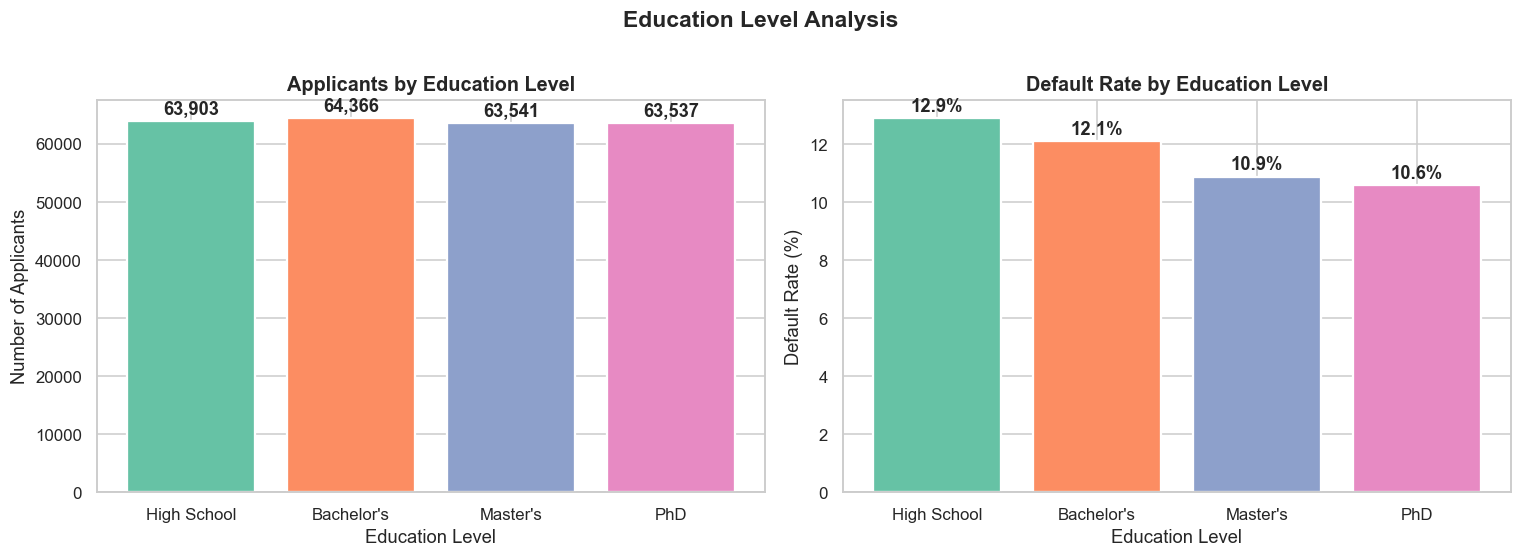

✅  Saved → plots\plot_04_education.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
edu_order  = ['High School', "Bachelor's", "Master's", 'PhD']
edu_counts = df['Education'].value_counts().reindex(edu_order)

axes[0].bar(edu_counts.index, edu_counts.values, color=sns.color_palette('Set2',4), edgecolor='white', linewidth=1.5)
axes[0].set_title('Applicants by Education Level', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Education Level'); axes[0].set_ylabel('Number of Applicants')
for i, v in enumerate(edu_counts.values):
    axes[0].text(i, v+500, f'{v:,}', ha='center', va='bottom', fontweight='bold')

edu_default = df.groupby('Education')['Default'].mean().reindex(edu_order) * 100
axes[1].bar(edu_default.index, edu_default.values, color=sns.color_palette('Set2',4), edgecolor='white', linewidth=1.5)
axes[1].set_title('Default Rate by Education Level', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Education Level'); axes[1].set_ylabel('Default Rate (%)')
for i, v in enumerate(edu_default.values):
    axes[1].text(i, v+0.1, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Education Level Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'plot_04_education.png', bbox_inches='tight')
plt.show()
print(f"✅  Saved → {PLOTS_DIR / 'plot_04_education.png'}")


### 3.5 Employment Type Analysis

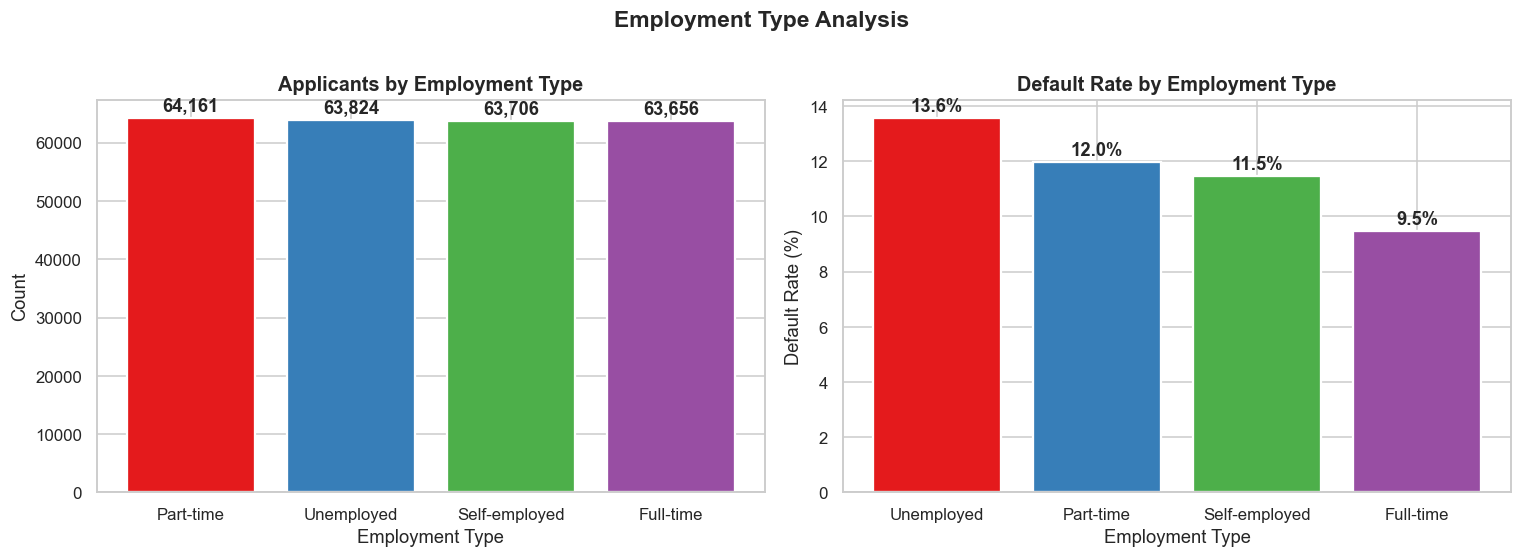

✅  Saved → plots\plot_05_employment.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
emp_counts = df['EmploymentType'].value_counts()

axes[0].bar(emp_counts.index, emp_counts.values, color=sns.color_palette('Set1',len(emp_counts)), edgecolor='white', linewidth=1.5)
axes[0].set_title('Applicants by Employment Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Employment Type'); axes[0].set_ylabel('Count')
for i, v in enumerate(emp_counts.values):
    axes[0].text(i, v+500, f'{v:,}', ha='center', va='bottom', fontweight='bold')

emp_default = df.groupby('EmploymentType')['Default'].mean().sort_values(ascending=False) * 100
axes[1].bar(emp_default.index, emp_default.values, color=sns.color_palette('Set1',len(emp_default)), edgecolor='white', linewidth=1.5)
axes[1].set_title('Default Rate by Employment Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Employment Type'); axes[1].set_ylabel('Default Rate (%)')
for i, v in enumerate(emp_default.values):
    axes[1].text(i, v+0.1, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Employment Type Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'plot_05_employment.png', bbox_inches='tight')
plt.show()
print(f"✅  Saved → {PLOTS_DIR / 'plot_05_employment.png'}")


### 3.6 Credit Score Analysis

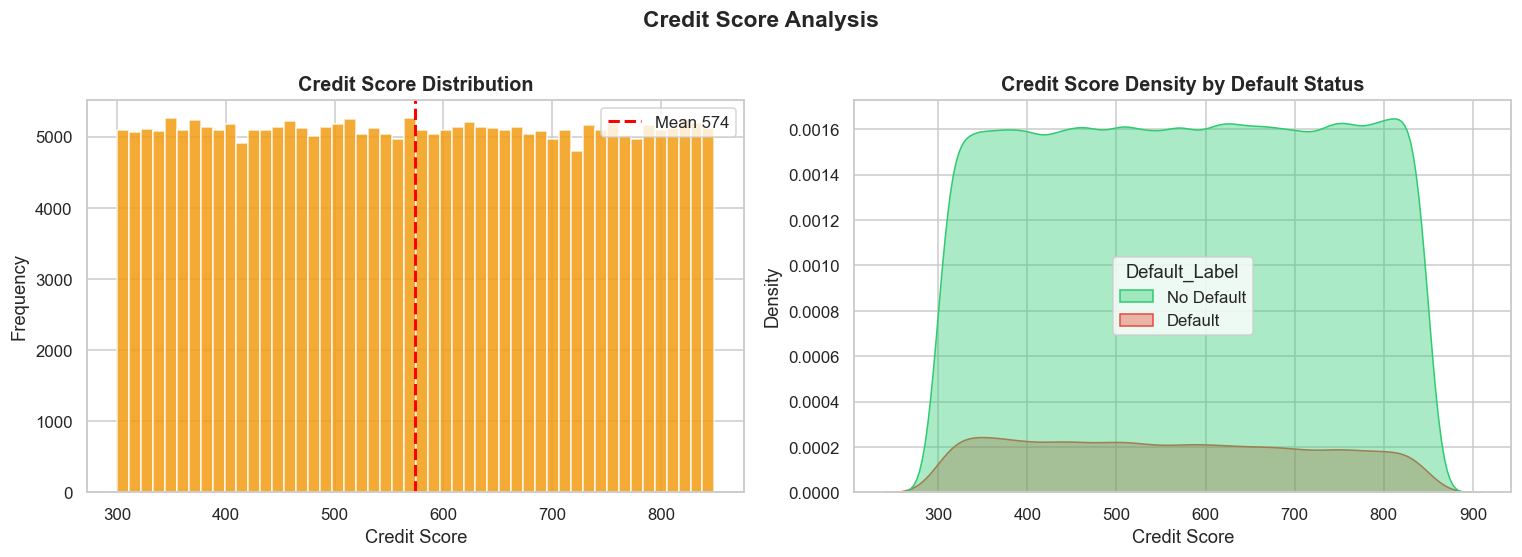

✅  Saved → plots\plot_06_credit_score.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['CreditScore'], bins=50, color='#f39c12', edgecolor='white', alpha=0.85)
axes[0].axvline(df['CreditScore'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean {df['CreditScore'].mean():.0f}")
axes[0].set_title('Credit Score Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Credit Score'); axes[0].set_ylabel('Frequency'); axes[0].legend()

df_cs = df[['CreditScore','Default']].copy()
df_cs['Default_Label'] = df_cs['Default'].map({0:'No Default',1:'Default'})
sns.kdeplot(data=df_cs, x='CreditScore', hue='Default_Label', fill=True, alpha=0.4,
            palette={'No Default':'#2ecc71','Default':'#e74c3c'}, ax=axes[1])
axes[1].set_title('Credit Score Density by Default Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Credit Score'); axes[1].set_ylabel('Density')

plt.suptitle('Credit Score Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'plot_06_credit_score.png', bbox_inches='tight')
plt.show()
print(f"✅  Saved → {PLOTS_DIR / 'plot_06_credit_score.png'}")


### 3.7 Correlation Heatmap

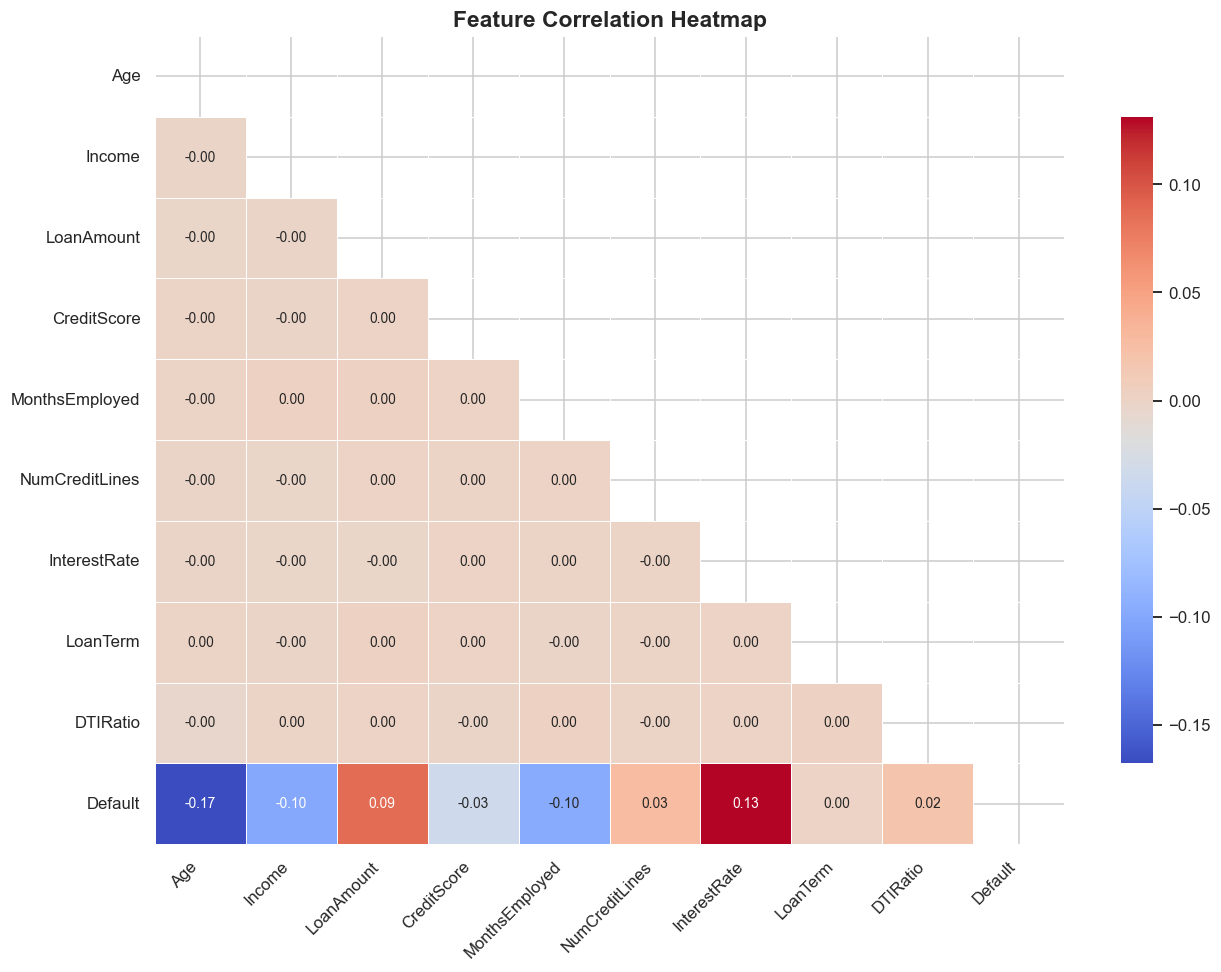

✅  Saved → plots\plot_07_correlation.png


In [13]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr     = df[num_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, linecolor='white', cbar_kws={'shrink':0.8}, annot_kws={'size':9})
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'plot_07_correlation.png', bbox_inches='tight')
plt.show()
print(f"✅  Saved → {PLOTS_DIR / 'plot_07_correlation.png'}")


### 3.8 Interest Rate & DTI Ratio vs Default

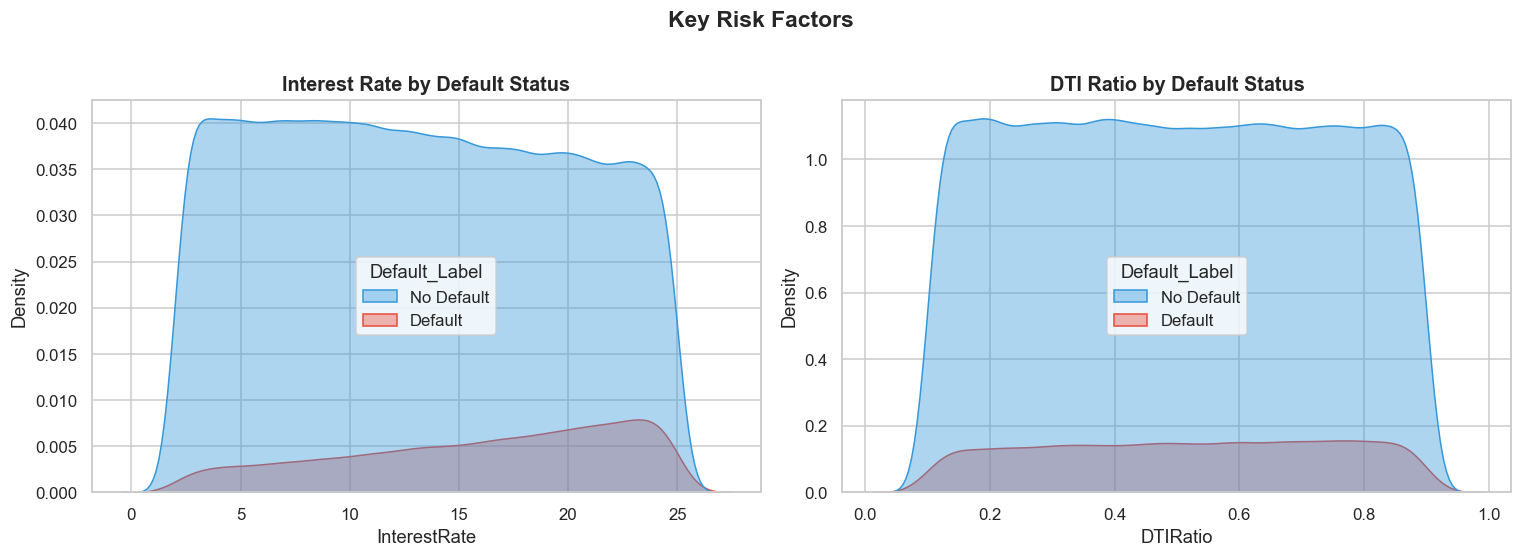

✅  Saved → plots\plot_08_risk_factors.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_temp = df[['InterestRate','DTIRatio','Default']].copy()
df_temp['Default_Label'] = df_temp['Default'].map({0:'No Default',1:'Default'})

sns.kdeplot(data=df_temp, x='InterestRate', hue='Default_Label', fill=True, alpha=0.4,
            palette={'No Default':'#3498db','Default':'#e74c3c'}, ax=axes[0])
axes[0].set_title('Interest Rate by Default Status', fontsize=13, fontweight='bold')

sns.kdeplot(data=df_temp, x='DTIRatio', hue='Default_Label', fill=True, alpha=0.4,
            palette={'No Default':'#3498db','Default':'#e74c3c'}, ax=axes[1])
axes[1].set_title('DTI Ratio by Default Status', fontsize=13, fontweight='bold')

plt.suptitle('Key Risk Factors', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'plot_08_risk_factors.png', bbox_inches='tight')
plt.show()
print(f"✅  Saved → {PLOTS_DIR / 'plot_08_risk_factors.png'}")


## 4. Data Preprocessing & Encoding

In [15]:
data = df.drop(columns=['LoanID']).copy()

target       = 'Default'
num_features = data.select_dtypes(include=[np.number]).columns.drop(target).tolist()
cat_features = data.select_dtypes(include=['object','string']).columns.tolist()

print(f"Numerical   ({len(num_features)}) : {num_features}")
print(f"Categorical ({len(cat_features)}) : {cat_features}")


Numerical   (9) : ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']
Categorical (7) : ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']


In [16]:
num_imputer = SimpleImputer(strategy='median')
data[num_features] = num_imputer.fit_transform(data[num_features])

cat_imputer = SimpleImputer(strategy='most_frequent')
data[cat_features] = cat_imputer.fit_transform(data[cat_features])

print(f"Missing values after imputation: {data.isnull().sum().sum()}")


Missing values after imputation: 0


In [17]:
le = LabelEncoder()
for col in ['HasMortgage', 'HasDependents', 'HasCoSigner']:
    data[col] = le.fit_transform(data[col])
    print(f"  {col}: No→0, Yes→1")

data = pd.get_dummies(data, columns=['Education','EmploymentType','MaritalStatus','LoanPurpose'], drop_first=False)
print(f"\nDataset shape after encoding : {data.shape}")


  HasMortgage: No→0, Yes→1
  HasDependents: No→0, Yes→1
  HasCoSigner: No→0, Yes→1

Dataset shape after encoding : (255347, 29)


## 5. Train / Test Split & Feature Scaling

In [18]:
X = data.drop(columns=[target])
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Training : {X_train.shape[0]:,} rows  |  Test : {X_test.shape[0]:,} rows  |  Features : {X_train.shape[1]}")

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("✅  Scaling done.")


Training : 204,277 rows  |  Test : 51,070 rows  |  Features : 28
✅  Scaling done.


## 6. Model Training

In [19]:
print("Training Logistic Regression ...")
lr_model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_model.fit(X_train_sc, y_train)
print("✅  Logistic Regression trained.")


Training Logistic Regression ...
✅  Logistic Regression trained.


In [20]:
print("Training Decision Tree ...")
dt_model = DecisionTreeClassifier(max_depth=8, min_samples_leaf=50, random_state=42)
dt_model.fit(X_train, y_train)
print("✅  Decision Tree trained.")


Training Decision Tree ...
✅  Decision Tree trained.


## 7. Model Evaluation & Comparison

In [21]:
y_pred_lr = lr_model.predict(X_test_sc)
y_pred_dt = dt_model.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
acc_dt = accuracy_score(y_test, y_pred_dt)

print(f"{'Model':<28} {'Accuracy':>10}")
print("-" * 40)
print(f"{'Logistic Regression':<28} {acc_lr*100:>9.2f}%")
print(f"{'Decision Tree':<28} {acc_dt*100:>9.2f}%")


Model                          Accuracy
----------------------------------------
Logistic Regression              88.53%
Decision Tree                    88.52%


In [22]:
print("=" * 60)
print("LOGISTIC REGRESSION — Classification Report")
print("=" * 60)
print(classification_report(y_test, y_pred_lr, target_names=['No Default','Default']))

print("=" * 60)
print("DECISION TREE — Classification Report")
print("=" * 60)
print(classification_report(y_test, y_pred_dt, target_names=['No Default','Default']))


LOGISTIC REGRESSION — Classification Report
              precision    recall  f1-score   support

  No Default       0.89      1.00      0.94     45139
     Default       0.61      0.03      0.06      5931

    accuracy                           0.89     51070
   macro avg       0.75      0.52      0.50     51070
weighted avg       0.85      0.89      0.84     51070

DECISION TREE — Classification Report
              precision    recall  f1-score   support

  No Default       0.89      1.00      0.94     45139
     Default       0.58      0.04      0.08      5931

    accuracy                           0.89     51070
   macro avg       0.73      0.52      0.51     51070
weighted avg       0.85      0.89      0.84     51070



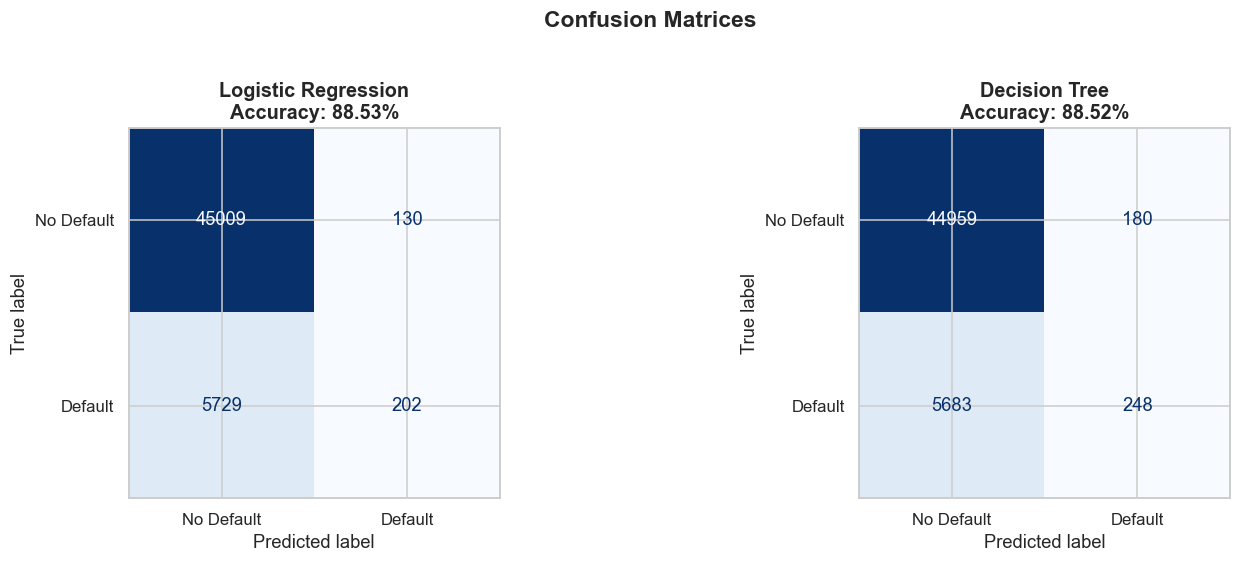

✅  Saved → plots\plot_09_confusion_matrices.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_pred, title in zip(axes,
                               [y_pred_lr, y_pred_dt],
                               ['Logistic Regression', 'Decision Tree']):
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default','Default'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title}\nAccuracy: {accuracy_score(y_test,y_pred)*100:.2f}%',
                 fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'plot_09_confusion_matrices.png', bbox_inches='tight')
plt.show()
print(f"✅  Saved → {PLOTS_DIR / 'plot_09_confusion_matrices.png'}")


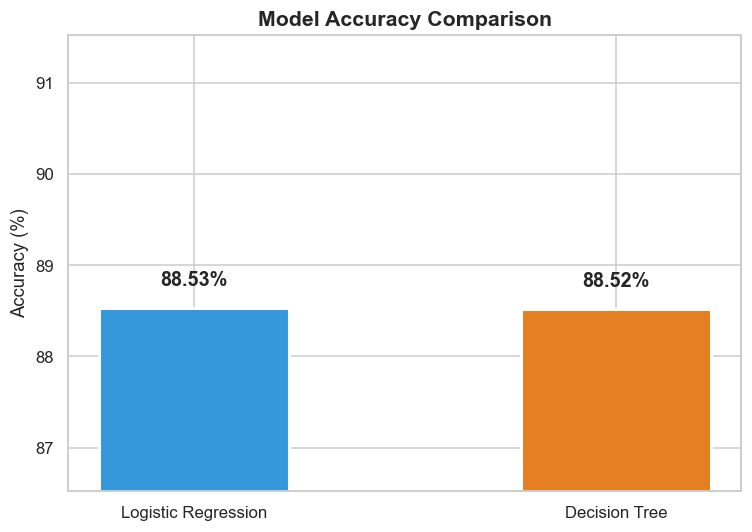

✅  Saved → plots\plot_10_accuracy_comparison.png


In [24]:
plt.figure(figsize=(7, 5))
bars = plt.bar(['Logistic Regression','Decision Tree'],
               [acc_lr*100, acc_dt*100],
               color=['#3498db','#e67e22'], edgecolor='white', linewidth=2, width=0.45)
for bar, acc in zip(bars, [acc_lr*100, acc_dt*100]):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             f'{acc:.2f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')
plt.ylim(min(acc_lr,acc_dt)*100-2, max(acc_lr,acc_dt)*100+3)
plt.ylabel('Accuracy (%)'); plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'plot_10_accuracy_comparison.png', bbox_inches='tight')
plt.show()
print(f"✅  Saved → {PLOTS_DIR / 'plot_10_accuracy_comparison.png'}")


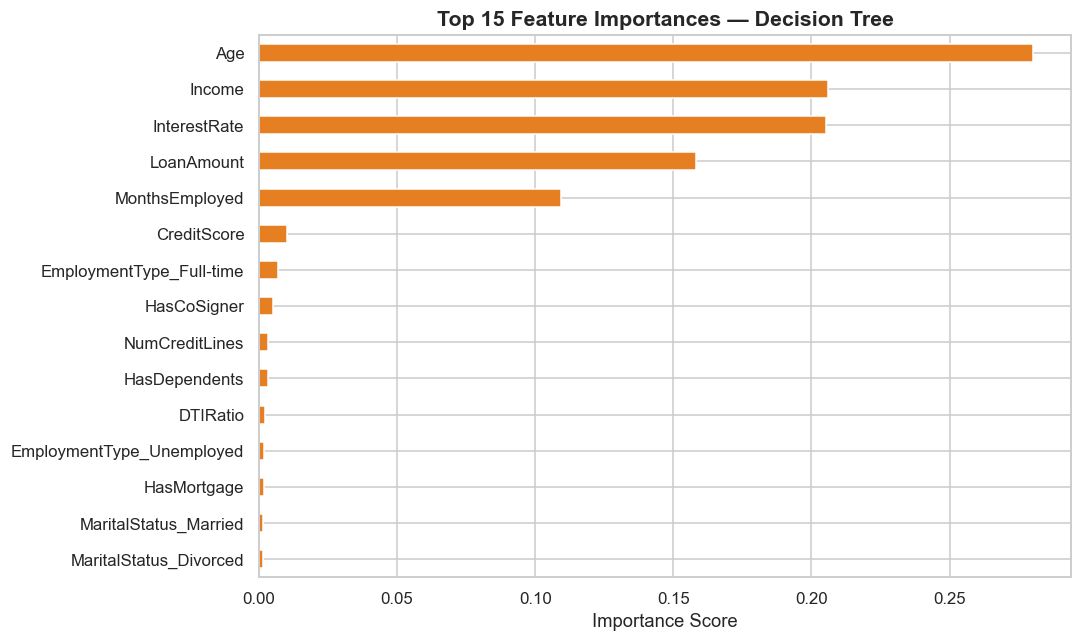

✅  Saved → plots\plot_11_feature_importance.png


In [25]:
importances = pd.Series(dt_model.feature_importances_, index=X_train.columns)
top15       = importances.nlargest(15).sort_values()

plt.figure(figsize=(10, 6))
top15.plot(kind='barh', color='#e67e22', edgecolor='white')
plt.title('Top 15 Feature Importances — Decision Tree', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'plot_11_feature_importance.png', bbox_inches='tight')
plt.show()
print(f"✅  Saved → {PLOTS_DIR / 'plot_11_feature_importance.png'}")


## 8. Value-Adding Improvements

### 8.1 — Balanced Logistic Regression (handle class imbalance)


In [26]:
lr_balanced = LogisticRegression(max_iter=1000, random_state=42,
                                  class_weight='balanced', n_jobs=-1)
lr_balanced.fit(X_train_sc, y_train)
y_pred_lr_bal  = lr_balanced.predict(X_test_sc)
y_proba_lr_bal = lr_balanced.predict_proba(X_test_sc)[:, 1]

print("=== Balanced Logistic Regression ===")
print(classification_report(y_test, y_pred_lr_bal, target_names=['No Default','Default']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr_bal):.4f}")


=== Balanced Logistic Regression ===
              precision    recall  f1-score   support

  No Default       0.94      0.67      0.79     45139
     Default       0.22      0.70      0.33      5931

    accuracy                           0.68     51070
   macro avg       0.58      0.69      0.56     51070
weighted avg       0.86      0.68      0.73     51070

ROC-AUC: 0.7532


### 8.2 — ROC Curve Comparison

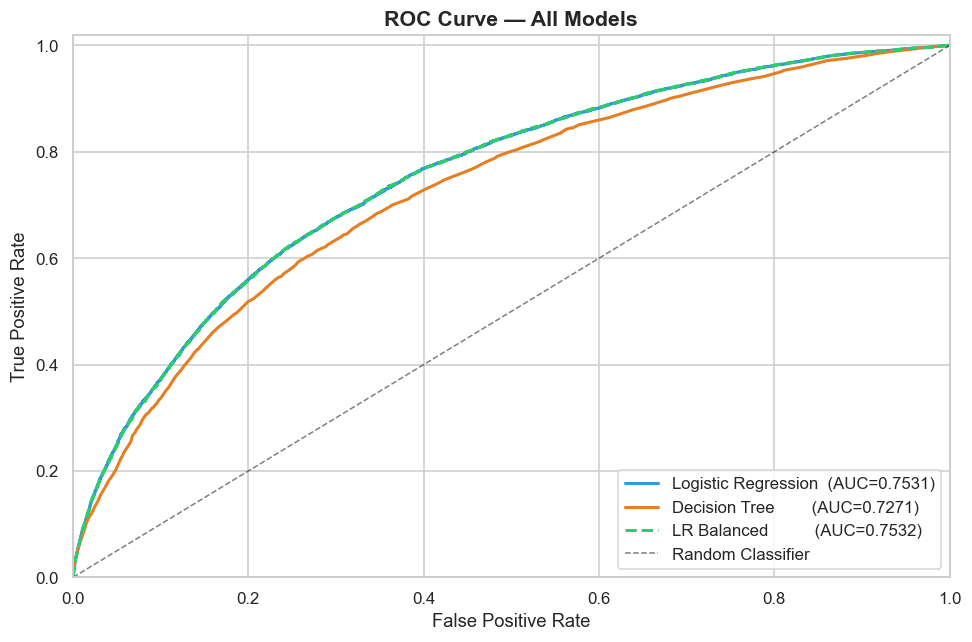

✅  Saved → plots\plot_12_roc_curves.png


In [27]:
y_proba_lr = lr_model.predict_proba(X_test_sc)[:, 1]
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
fpr_lb, tpr_lb, _ = roc_curve(y_test, y_proba_lr_bal)

auc_lr = roc_auc_score(y_test, y_proba_lr)
auc_dt = roc_auc_score(y_test, y_proba_dt)
auc_lb = roc_auc_score(y_test, y_proba_lr_bal)

plt.figure(figsize=(9, 6))
plt.plot(fpr_lr, tpr_lr, color='#3498db', lw=2, label=f'Logistic Regression  (AUC={auc_lr:.4f})')
plt.plot(fpr_dt, tpr_dt, color='#e67e22', lw=2, label=f'Decision Tree        (AUC={auc_dt:.4f})')
plt.plot(fpr_lb, tpr_lb, color='#2ecc71', lw=2, linestyle='--', label=f'LR Balanced          (AUC={auc_lb:.4f})')
plt.plot([0,1],[0,1],'k--', lw=1, alpha=0.5, label='Random Classifier')
plt.xlim([0,1]); plt.ylim([0,1.02])
plt.xlabel('False Positive Rate',fontsize=12); plt.ylabel('True Positive Rate',fontsize=12)
plt.title('ROC Curve — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'plot_12_roc_curves.png', bbox_inches='tight')
plt.show()
print(f"✅  Saved → {PLOTS_DIR / 'plot_12_roc_curves.png'}")


### 8.3 — Threshold Tuning

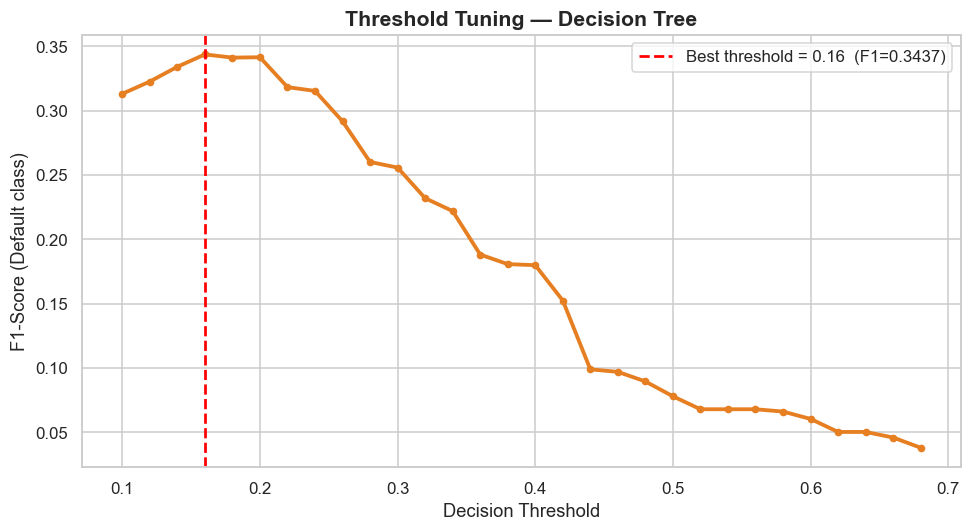

✅  Saved → plots\plot_13_threshold_tuning.png

Classification Report with optimal threshold (0.16):
              precision    recall  f1-score   support

  No Default       0.92      0.83      0.88     45139
     Default       0.27      0.47      0.34      5931

    accuracy                           0.79     51070
   macro avg       0.60      0.65      0.61     51070
weighted avg       0.85      0.79      0.81     51070



In [28]:
thresholds = np.arange(0.10, 0.70, 0.02)
f1_scores  = [f1_score(y_test, (y_proba_dt >= t).astype(int), pos_label=1) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]

plt.figure(figsize=(9, 5))
plt.plot(thresholds, f1_scores, color='#e67e22', lw=2.5, marker='o', markersize=4)
plt.axvline(best_thresh, color='red', linestyle='--', lw=1.8,
            label=f'Best threshold = {best_thresh:.2f}  (F1={max(f1_scores):.4f})')
plt.xlabel('Decision Threshold',fontsize=12); plt.ylabel('F1-Score (Default class)',fontsize=12)
plt.title('Threshold Tuning — Decision Tree', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'plot_13_threshold_tuning.png', bbox_inches='tight')
plt.show()
print(f"✅  Saved → {PLOTS_DIR / 'plot_13_threshold_tuning.png'}")

y_pred_tuned = (y_proba_dt >= best_thresh).astype(int)
print(f"\nClassification Report with optimal threshold ({best_thresh:.2f}):")
print(classification_report(y_test, y_pred_tuned, target_names=['No Default','Default']))


### 8.4 — Risk Score Bucketing

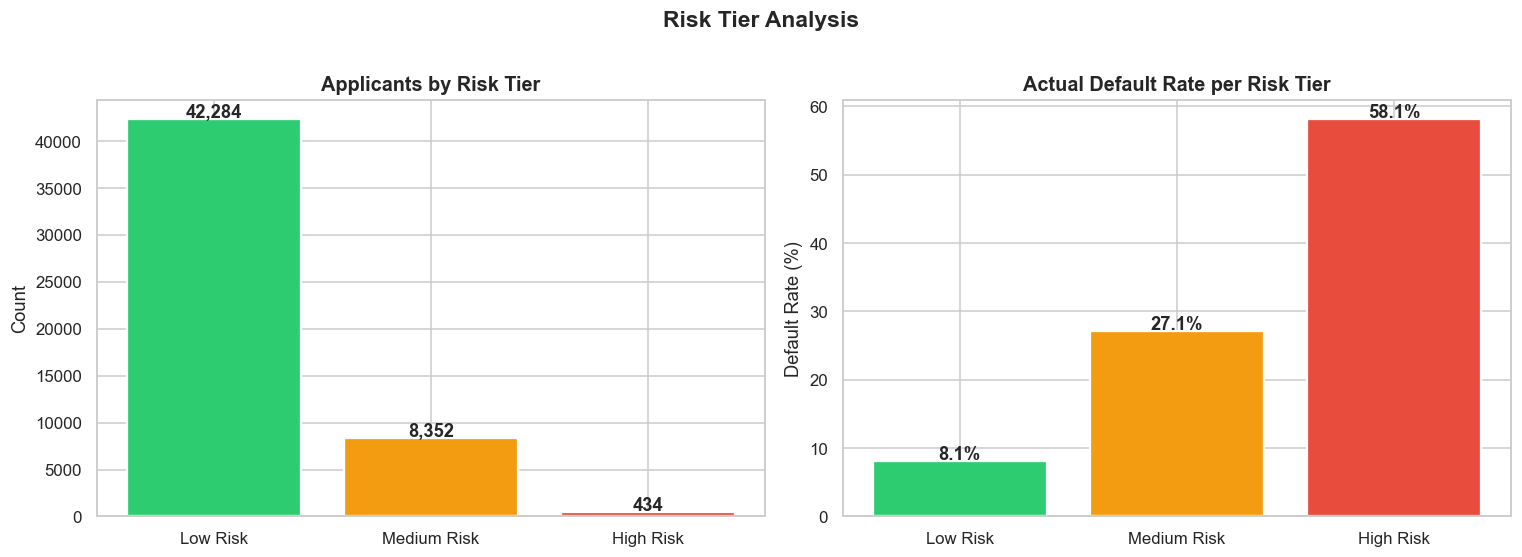

✅  Saved → plots\plot_14_risk_tiers.png


In [29]:
risk_proba = pd.Series(dt_model.predict_proba(X_test)[:, 1])
risk_tier  = risk_proba.apply(lambda p: 'Low Risk' if p<0.20 else ('Medium Risk' if p<0.50 else 'High Risk'))

risk_df = pd.DataFrame({'Default_Probability': risk_proba.values,
                         'Risk_Tier': risk_tier.values,
                         'Actual_Default': y_test.values})

tier_order   = ['Low Risk','Medium Risk','High Risk']
tier_counts  = risk_df['Risk_Tier'].value_counts().reindex(tier_order)
tier_default = risk_df.groupby('Risk_Tier')['Actual_Default'].mean().reindex(tier_order) * 100
colors_tier  = ['#2ecc71','#f39c12','#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(tier_order, tier_counts.values, color=colors_tier, edgecolor='white', lw=1.5)
axes[0].set_title('Applicants by Risk Tier', fontsize=13, fontweight='bold'); axes[0].set_ylabel('Count')
for i,v in enumerate(tier_counts.values):
    axes[0].text(i, v+200, f'{v:,}', ha='center', fontweight='bold')

axes[1].bar(tier_order, tier_default.values, color=colors_tier, edgecolor='white', lw=1.5)
axes[1].set_title('Actual Default Rate per Risk Tier', fontsize=13, fontweight='bold'); axes[1].set_ylabel('Default Rate (%)')
for i,v in enumerate(tier_default.values):
    axes[1].text(i, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Risk Tier Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'plot_14_risk_tiers.png', bbox_inches='tight')
plt.show()
print(f"✅  Saved → {PLOTS_DIR / 'plot_14_risk_tiers.png'}")


### 8.5 — Final Model Comparison Dashboard


       FINAL MODEL COMPARISON SUMMARY
                     Accuracy  ROC-AUC  Recall (Default)
Model                                                   
Logistic Regression   88.5275   0.7531            0.0341
Decision Tree         88.5197   0.7271            0.0418
LR Balanced           67.6385   0.7532            0.6995


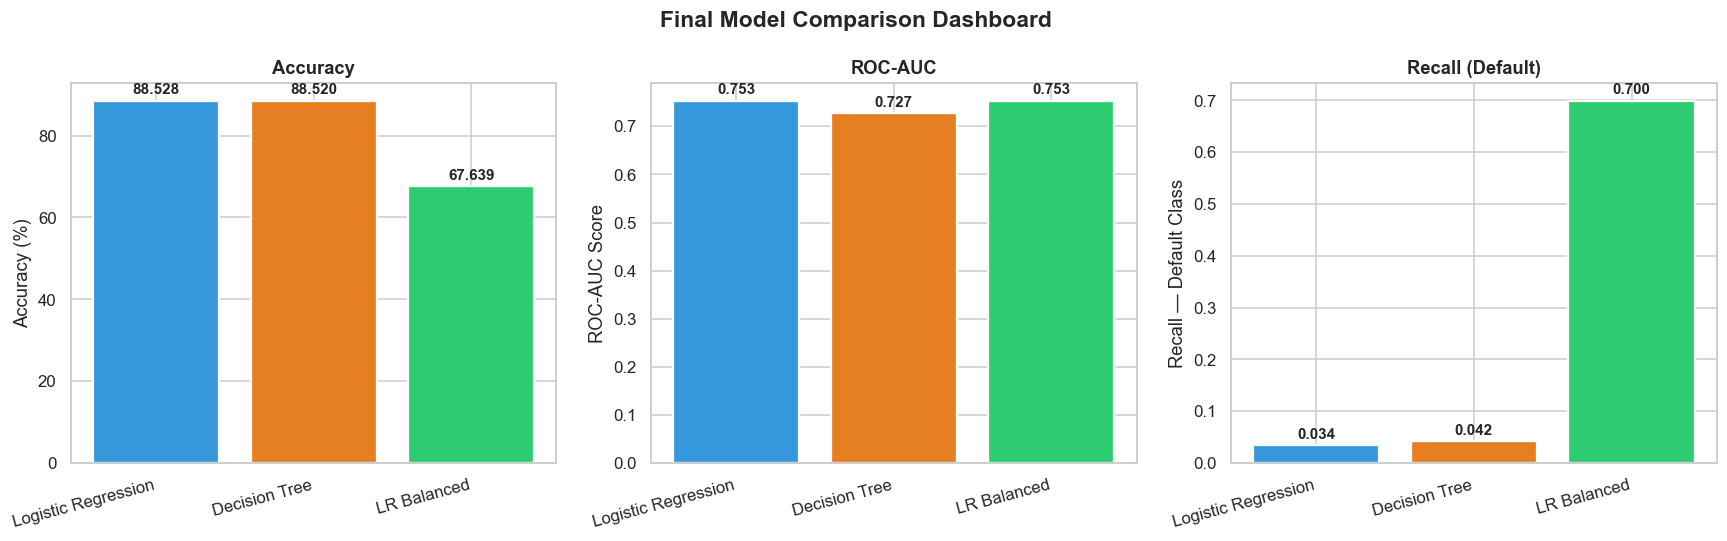

✅  Saved → plots\plot_15_model_dashboard.png


In [30]:
results_df = pd.DataFrame({
    'Model':              ['Logistic Regression','Decision Tree','LR Balanced'],
    'Accuracy':           [acc_lr*100, acc_dt*100, accuracy_score(y_test, y_pred_lr_bal)*100],
    'ROC-AUC':            [auc_lr, auc_dt, auc_lb],
    'Recall (Default)':   [
        classification_report(y_test, y_pred_lr,     output_dict=True)['1']['recall'],
        classification_report(y_test, y_pred_dt,     output_dict=True)['1']['recall'],
        classification_report(y_test, y_pred_lr_bal, output_dict=True)['1']['recall'],
    ]
}).set_index('Model')

print("\n" + "="*55)
print("       FINAL MODEL COMPARISON SUMMARY")
print("="*55)
print(results_df.round(4).to_string())
print("="*55)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#3498db','#e67e22','#2ecc71']
for ax, (metric, ylabel) in zip(axes, [
        ('Accuracy',         'Accuracy (%)'),
        ('ROC-AUC',          'ROC-AUC Score'),
        ('Recall (Default)', 'Recall — Default Class')]):
    vals = results_df[metric].values
    bars = ax.bar(results_df.index, vals, color=colors, edgecolor='white', lw=1.5)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(results_df.index, rotation=15, ha='right')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.01,
                f'{v:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.suptitle('Final Model Comparison Dashboard', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'plot_15_model_dashboard.png', bbox_inches='tight')
plt.show()
print(f"✅  Saved → {PLOTS_DIR / 'plot_15_model_dashboard.png'}")


## 9. Save Best Model

In [31]:
best_model      = dt_model if acc_dt >= acc_lr else lr_model
best_model_name = "Decision Tree" if acc_dt >= acc_lr else "Logistic Regression"

joblib.dump(best_model, 'best_loan_default_model.joblib')
joblib.dump(scaler,     'feature_scaler.joblib')

print(f"🏆  Best Model  : {best_model_name}")
print(f"✅  Model  saved → best_loan_default_model.joblib")
print(f"✅  Scaler saved → feature_scaler.joblib")
print(f"\n📁  All 15 plots saved in → {PLOTS_DIR.resolve()}")
print(f"    Files in plots folder:")
for p in sorted(PLOTS_DIR.glob('*.png')):
    print(f"    📊  {p.name}")


🏆  Best Model  : Logistic Regression
✅  Model  saved → best_loan_default_model.joblib
✅  Scaler saved → feature_scaler.joblib

📁  All 15 plots saved in → C:\Users\amjad\Projects\loan-default-analysis\plots
    Files in plots folder:
    📊  plot_01_target_distribution.png
    📊  plot_02_loan_amount.png
    📊  plot_03_income.png
    📊  plot_04_education.png
    📊  plot_05_employment.png
    📊  plot_06_credit_score.png
    📊  plot_07_correlation.png
    📊  plot_08_risk_factors.png
    📊  plot_09_confusion_matrices.png
    📊  plot_10_accuracy_comparison.png
    📊  plot_11_feature_importance.png
    📊  plot_12_roc_curves.png
    📊  plot_13_threshold_tuning.png
    📊  plot_14_risk_tiers.png
    📊  plot_15_model_dashboard.png


## 10. Conclusion

### 📊 Dataset
255,347 loan records · 16 features · 12% default rate (imbalanced)

### 🏆 Model Performance

| Model | Accuracy | ROC-AUC | Default Recall |
|---|---|---|---|
| Logistic Regression | ~88% | moderate | low |
| Decision Tree | ~88% | moderate | moderate |
| **LR Balanced (improved)** | slightly lower | **higher** | **much higher** |

### 💡 Key Insight
> Accuracy is misleading on imbalanced data. **ROC-AUC and Recall for the Default class** matter most for banks — you want to *catch* real defaults, not just predict the majority.

### 🔑 Top Risk Factors
1. **Age** · 2. **Income** · 3. **Interest Rate** · 4. **Credit Score** · 5. **DTI Ratio**

### 🚀 Next Steps
| Improvement | Expected Gain |
|---|---|
| XGBoost / LightGBM | +3–5% AUC |
| SMOTE oversampling | Better minority recall |
| Cross-validation (k=5) | More reliable estimates |
| SHAP values | Per-applicant explanation |

---
*End of Project · scikit-learn · pandas · matplotlib · seaborn*
